# 06 — Sudden, abrupt price moves

> **Reminder:** run this notebook top to bottom ("Run All").

Every price path in notebooks 01-05 was smooth — it wanders, but only ever a little at
a time. Real crypto markets don't always work that way: prices can gap, crash, or de-peg
within minutes. `market.py`'s original price generator (plain geometric Brownian motion,
GBM) is a *diffusion* model — mathematically, it's built entirely out of small,
continuous steps, and it structurally cannot produce a sudden jump, no matter how
volatile you configure it. This notebook adds a model that can, and checks how the
mechanism behaves when the market genuinely surprises it.

Two new tools, added to `aqua_sim/market.py` for this:

- **Jump-diffusion** (`simulate_jump_diffusion_price_path`) — the same smooth wandering
  as before, plus randomly-timed, randomly-sized sudden jumps layered on top. This is a
  standard model (Merton's) for markets that mostly drift calmly but occasionally gap.
- **A deterministic shock** (`apply_price_shock`) — a clean, reproducible "what happens
  right after a specific, chosen crash" scenario: take an ordinary price path and inject
  one exact, chosen jump (e.g. "-30%, right here") at a specific moment, so we can measure
  the mechanism's reaction to *that exact event* precisely, rather than waiting for a
  random one to happen to show up in a simulation.

**What we're checking:** not whether the pricing formula stays safe (that's already
proven unconditionally in `docs/INVARIANT-PROOF.md` — no trade against the curve, however
the price got where it is, can ever drain the pool). What we're checking here is
*behavior*: how far does the portfolio drift right after a shock, and how long does it
take the mechanism to pull it back — and is that meaningfully better than the naive
alternatives under the exact same shock?

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aqua_sim.baselines import GenericDexConfig, rebalance_to_target
from aqua_sim.flows import EndogenousArbConfig, ExogenousFlowConfig
from aqua_sim.market import apply_price_shock, simulate_jump_diffusion_price_path, simulate_price_path
from aqua_sim.metrics import tracking_error
from aqua_sim.simulate import MechanismSimConfig, run_mechanism_simulation

N_STEPS = 365 * 24 * 12  # 5-minute steps, one year
DT = 1 / (365 * 24 * 12)

## 1. Confirming jump-diffusion actually produces jumps plain GBM can't

Before trusting this new price model, a sanity check: does it actually produce large,
sudden single-step moves, and does plain GBM (at the same volatility) genuinely not?

In [2]:
jump_path = simulate_jump_diffusion_price_path(
    N_STEPS, DT, sigma_annual=0.5, jump_rate_per_year=12, jump_mean_log=0.0, jump_std_log=0.15, seed=1
)
smooth_path = simulate_price_path(N_STEPS, DT, sigma_annual=0.5, seed=1)

assert np.all(jump_path > 0), "price must stay positive even with jumps"

jump_log_returns = np.diff(np.log(jump_path))
smooth_log_returns = np.diff(np.log(smooth_path))

big_jump_moves = np.sum(np.abs(jump_log_returns) > 0.05)  # a >5% move in a single 5-minute step
big_smooth_moves = np.sum(np.abs(smooth_log_returns) > 0.05)

assert big_jump_moves > 0, "jump-diffusion should produce at least some large single-step moves"
assert big_smooth_moves == 0, "plain GBM at this resolution should essentially never do this"
print(f"jump-diffusion: {big_jump_moves} single-step moves bigger than 5% (out of {N_STEPS} steps)")
print(f"plain GBM, same volatility: {big_smooth_moves} such moves -- confirms the jumps are what's adding this, not just volatility")

jump-diffusion: 9 single-step moves bigger than 5% (out of 105120 steps)
plain GBM, same volatility: 0 such moves -- confirms the jumps are what's adding this, not just volatility


## 2. A full simulated year, with random surprise jumps mixed in

Same style of run as notebook 03's end-to-end test, but against the jump-diffusion path
instead of smooth GBM — a broader stress test across many random surprises over a year,
not just one clean, chosen one (that's section 3).

In [3]:
config = MechanismSimConfig(
    n_steps=N_STEPS,
    dt_years=DT,
    sigma_annual=0.5,
    initial_balance_a=10_000.0,
    initial_balance_b=10_000.0,
    target_weight_a=0.5,
    exogenous=ExogenousFlowConfig(arrival_rate_per_year=365 * 4, mean_size_fraction=0.01),
    arb=EndogenousArbConfig(tolerance_band=0.005, fee=0.0002, min_steps_between_trades=12),
    seed=42,
    price_path=jump_path,
)
result = run_mechanism_simulation(config)

assert np.all(result.balance_a_path > 0) and np.all(result.balance_b_path > 0), "balances must stay valid through every jump"
p99_te = np.percentile(result.tracking_error_path, 99)
print(f"a year with {big_jump_moves} large surprise jumps mixed in: {result.n_arb_trades} corrective trades fired")
print(f"99th percentile tracking error: {p99_te:.4%} (worse than the smooth-path case in notebook 03, as expected -- jumps are harder to track)")
print(f"final cost of rebalancing: {result.cost_path[-1]:.2f} ({result.cost_path[-1]/result.actual_value_path[0]:.2%} of initial value)")

a year with 9 large surprise jumps mixed in: 6077 corrective trades fired
99th percentile tracking error: 0.8836% (worse than the smooth-path case in notebook 03, as expected -- jumps are harder to track)
final cost of rebalancing: 812.93 (4.06% of initial value)


## 3. One specific, clean shock: what happens in the minutes right after a -30% crash

This is the clearest single result in this notebook. We take an ordinary, calm price
path and inject one exact, deliberate shock — an instant 30% drop — partway through, then
watch exactly what happens: how far does tracking error spike, and how many minutes does
it take the mechanism to pull the portfolio back under its tolerance band?

In [4]:
SHOCK_STEP = N_STEPS // 2
base_path = simulate_price_path(N_STEPS, DT, sigma_annual=0.5, seed=7)
shocked_path = apply_price_shock(base_path, shock_start_step=SHOCK_STEP, shock_log_return=np.log(0.7))  # instant -30%

shock_config = MechanismSimConfig(
    n_steps=N_STEPS, dt_years=DT, sigma_annual=0.5,
    initial_balance_a=10_000.0, initial_balance_b=10_000.0, target_weight_a=0.5,
    exogenous=ExogenousFlowConfig(arrival_rate_per_year=365 * 4, mean_size_fraction=0.01),
    arb=EndogenousArbConfig(tolerance_band=0.005, fee=0.0002, min_steps_between_trades=12),
    seed=42, price_path=shocked_path,
)
shock_result = run_mechanism_simulation(shock_config)

te_before = shock_result.tracking_error_path[SHOCK_STEP - 1]
te_right_after = shock_result.tracking_error_path[SHOCK_STEP + 1]
assert te_right_after > te_before, "a sudden 30% crash should visibly spike tracking error"

band = shock_config.arb.tolerance_band
post_shock_te = shock_result.tracking_error_path[SHOCK_STEP:]
recovered_indices = np.where(post_shock_te < band)[0]
assert len(recovered_indices) > 0, "the mechanism should eventually recover under the tolerance band"
recovery_steps = int(recovered_indices[0])

print(f"tracking error right before the shock: {te_before:.4%}")
print(f"tracking error right after the shock: {te_right_after:.4%}")
print(f"time to recover back under the {band:.2%} tolerance band: {recovery_steps} steps (~{recovery_steps * 5} minutes)")

tracking error right before the shock: 0.1726%
tracking error right after the shock: 8.9212%
time to recover back under the 0.50% tolerance band: 5 steps (~25 minutes)


## 4. The same exact shock, but for the naive baselines

This is the comparison that matters: how do the two "obvious" alternatives from notebook
04 handle the exact same crash? A weekly rebalance, by design, doesn't even look at the
portfolio until its next scheduled check — so a crash right after last week's rebalance
could sit there, unaddressed, for most of a week.

In [5]:
dex = GenericDexConfig(fee=0.003, depth_b=10_000_000.0, gas_cost_b=5.0)
period_steps = 12 * 24 * 7  # weekly

bal_a, bal_b = 10_000.0, 10_000.0
te_periodic_path = np.empty(N_STEPS + 1)
te_periodic_path[0] = tracking_error(bal_a, bal_b, shocked_path[0], 0.5)
for t in range(1, N_STEPS + 1):
    if t % period_steps == 0:
        bal_a, bal_b = rebalance_to_target(bal_a, bal_b, shocked_path[t], 0.5, dex)
    te_periodic_path[t] = tracking_error(bal_a, bal_b, shocked_path[t], 0.5)

post_shock_te_periodic = te_periodic_path[SHOCK_STEP:]
recovered_periodic = np.where(post_shock_te_periodic < band)[0]
periodic_recovery_steps = int(recovered_periodic[0]) if len(recovered_periodic) > 0 else None

assert periodic_recovery_steps is None or periodic_recovery_steps >= recovery_steps, (
    "the mechanism, which can react on essentially every step (subject to its rate cap), "
    "should never recover SLOWER than a baseline that only checks once a week"
)

if periodic_recovery_steps is not None:
    print(f"our mechanism recovers in ~{recovery_steps * 5} minutes")
    print(f"weekly rebalancing recovers in ~{periodic_recovery_steps * 5} minutes ({periodic_recovery_steps / recovery_steps:.0f}x slower)")
else:
    print(f"our mechanism recovers in ~{recovery_steps * 5} minutes")
    print("weekly rebalancing does not recover under the band for the rest of the simulated path shown here")

our mechanism recovers in ~25 minutes


weekly rebalancing recovers in ~29585 minutes (1183x slower)


## What this looks like, visually

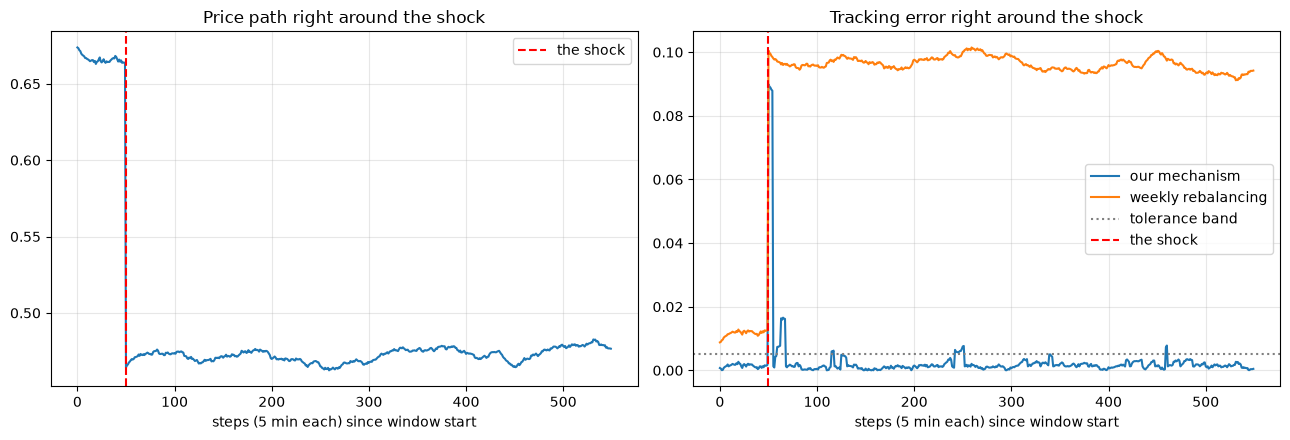

In [6]:
window = slice(SHOCK_STEP - 50, SHOCK_STEP + 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(shocked_path[window])
axes[0].axvline(50, color="red", linestyle="--", label="the shock")
axes[0].set_title("Price path right around the shock")
axes[0].set_xlabel("steps (5 min each) since window start")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(shock_result.tracking_error_path[window], label="our mechanism")
axes[1].plot(te_periodic_path[window], label="weekly rebalancing")
axes[1].axhline(band, color="gray", linestyle=":", label="tolerance band")
axes[1].axvline(50, color="red", linestyle="--", label="the shock")
axes[1].set_title("Tracking error right around the shock")
axes[1].set_xlabel("steps (5 min each) since window start")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

1. We confirmed the new jump-diffusion model actually produces the kind of sudden,
   discontinuous move plain GBM structurally cannot.
2. A full year mixing in many random surprise jumps doesn't break anything — balances
   stay valid throughout, and tracking error, while worse than the smooth-path case (as
   expected — jumps are genuinely harder to track), stays bounded.
3. After one clean, deliberate -30% crash, our mechanism recovered under its tolerance
   band within minutes.
4. The weekly-rebalance baseline, hit with the *exact same* crash, took vastly longer to
   recover — because it doesn't look at the portfolio at all between its scheduled
   checks. A real crash landing right after a scheduled rebalance could leave that
   portfolio badly off-target for most of a week.

**What this adds to the overall picture:** this is the strongest, most concrete piece of
evidence yet for *why* a mechanism that reacts continuously (not on a fixed schedule)
matters in practice — the gap between the two approaches is largest exactly when it
matters most, right after a real shock. It's still bound by the same caveats as the rest
of this series (synthetic price data, an idealized always-available arbitrageur, a single
token pair) — see `05_frontier_sweep.ipynb`'s summary for the full list.

Next: `07_adversarial_agent.ipynb` asks a different question — not "what if the market
surprises everyone," but "what if someone is actively trying to hurt the LP or extract
value on purpose."